DEBUG:commons:version: 6.2.4 *
DEBUG:typing:version: 6.2.3
DEBUG:aido_schemas:aido-protocols version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:nodes:version 6.2.17 path /usr/local/lib/python3.8/dist-packages pyparsing 2.4.6
DEBUG:dt_protocols:dt-protocols version 6.2.35 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_world:duckietown-world version 6.4.3 path /usr/local/lib/python3.8/dist-packages
DEBUG:geometry:PyGeometry-z6 version 2.1.4 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_challenges:duckietown_challenges version 6.5.2 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_build_utils:duckietown_build_utils version 6.2.78 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_docker_utils:duckietown_docker_utils version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:ipce:version 6.1.2 path /usr/local/lib/python3.8/dist-packages


PlanStep
│ duration: 11.780972450961723
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: 7.639437268410977
90.0


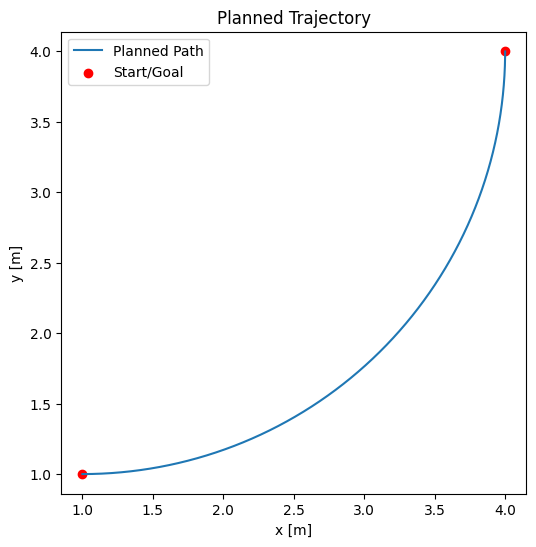

In [1]:
from planning.planner import connect_poses_with_curvature
import matplotlib.pyplot as plt
from aido_schemas import Context, FriendlyPose
from dt_protocols import PlanningSetup, Rectangle, Circle, PlacedPrimitive
import math
import numpy as np

ps = PlanningSetup(
    bounds=Rectangle(xmin=0.0, ymin=0.0, xmax=3.0, ymax=3.0),
    max_linear_velocity_m_s=0.4,
    min_linear_velocity_m_s=-0.3,
    max_angular_velocity_deg_s=30.0,
    max_curvature=math.inf,
    tolerance_xy_m=0.05,
    tolerance_theta_deg=20.0,
    environment=[],
    body=[]
)

start = FriendlyPose(x=1, y=1, theta_deg=0.0)
goal = FriendlyPose(x=4, y=4, theta_deg=45.0)

plan, new_heading = connect_poses_with_curvature(ps, start, goal)
print(plan)
print(new_heading)

def simulate_plan(start_pose, plan):
    """
    Simulate the trajectory given a start pose and a plan (list of PlanStep).
    Returns arrays of x, y, theta.
    """
    x, y, theta_deg = start_pose.x, start_pose.y, start_pose.theta_deg
    xs, ys, thetas = [x], [y], [theta_deg]
    for step in plan:
        duration = step.duration
        v = step.velocity_x_m_s
        w_deg = step.angular_velocity_deg_s
        w = np.deg2rad(w_deg)
        theta = np.deg2rad(theta_deg)
        # Simulate in small increments for smoothness
        dt = 0.001
        n = int(duration / dt)
        for _ in range(n):
            if abs(w) < 1e-6:
                # Straight line
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
            else:
                # Arc
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
                theta += w * dt
            xs.append(x)
            ys.append(y)
            thetas.append(np.rad2deg(theta))
        theta_deg = np.rad2deg(theta)
    return np.array(xs), np.array(ys), np.array(thetas)

# Simulate and plot
xs, ys, thetas = simulate_plan(start, [plan])

plt.figure(figsize=(6,6))
plt.plot(xs, ys, label="Planned Path")
plt.scatter([start.x, goal.x], [start.y, goal.y], c='red', label="Start/Goal")
plt.axis('equal')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Planned Trajectory")
plt.legend()
plt.show()

PlanStep
│ duration: 3.0
│ velocity_x_m_s: 0.2617993877991495
│ angular_velocity_deg_s: 30.0
270.0


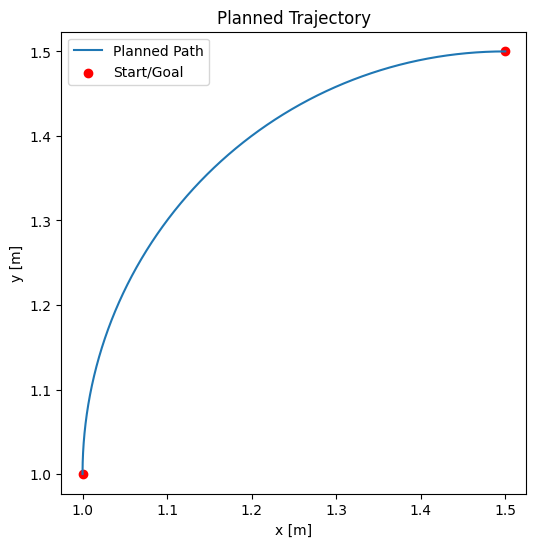

In [2]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=180)
goal = FriendlyPose(x=1, y=1, theta_deg=45.0)

plan, new_heading = connect_poses_with_curvature(ps, start, goal)
print(plan)
print(new_heading)

# Simulate and plot
xs, ys, thetas = simulate_plan(start, [plan])

plt.figure(figsize=(6,6))
plt.plot(xs, ys, label="Planned Path")
plt.scatter([start.x, goal.x], [start.y, goal.y], c='red', label="Start/Goal")
plt.axis('equal')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Planned Trajectory")
plt.legend()
plt.show()

PlanStep
│ duration: 4.771003411805198
│ velocity_x_m_s: 0.17453292519943298
│ angular_velocity_deg_s: 30.0
323.13010235415595


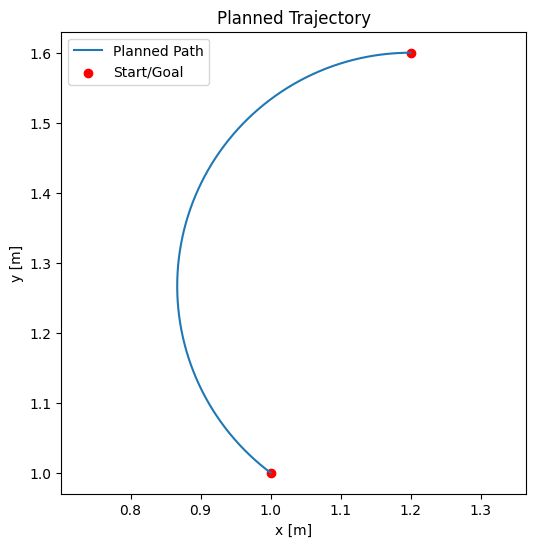

In [3]:
start = FriendlyPose(x=1.2, y=1.6, theta_deg=180)
goal = FriendlyPose(x=1, y=1, theta_deg=45.0)

plan, new_heading = connect_poses_with_curvature(ps, start, goal)
print(plan)
print(new_heading)

# Simulate and plot
xs, ys, thetas = simulate_plan(start, [plan])

plt.figure(figsize=(6,6))
plt.plot(xs, ys, label="Planned Path")
plt.scatter([start.x, goal.x], [start.y, goal.y], c='red', label="Start/Goal")
plt.axis('equal')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Planned Trajectory")
plt.legend()
plt.show()

PlanStep
│ duration: 0.1250000000000001
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: 0.0
0


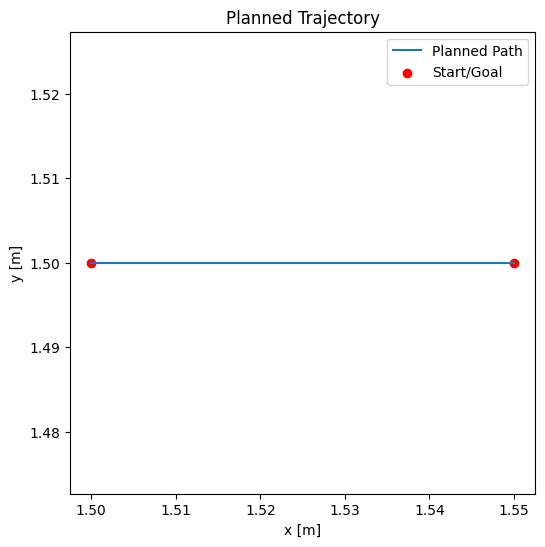

In [4]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=0)
goal = FriendlyPose(x=1.55, y=1.5, theta_deg=45.0)

plan, new_heading = connect_poses_with_curvature(ps, start, goal)
print(plan)
print(new_heading)

# Simulate and plot
xs, ys, thetas = simulate_plan(start, [plan])

plt.figure(figsize=(6,6))
plt.plot(xs, ys, label="Planned Path")
plt.scatter([start.x, goal.x], [start.y, goal.y], c='red', label="Start/Goal")
plt.axis('equal')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Planned Trajectory")
plt.legend()
plt.show()

PlanStep
│ duration: 6.0
│ velocity_x_m_s: 0.013089969389957483
│ angular_velocity_deg_s: 30.0
180.0


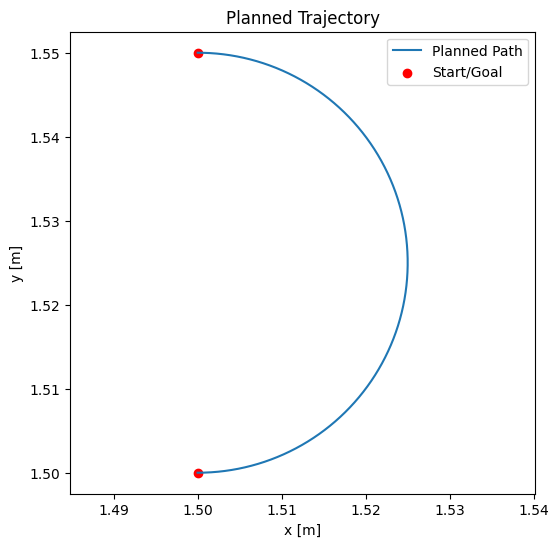

In [5]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=0)
goal = FriendlyPose(x=1.5, y=1.55, theta_deg=45.0)

plan, new_heading = connect_poses_with_curvature(ps, start, goal)
print(plan)
print(new_heading)

# Simulate and plot
xs, ys, thetas = simulate_plan(start, [plan])

plt.figure(figsize=(6,6))
plt.plot(xs, ys, label="Planned Path")
plt.scatter([start.x, goal.x], [start.y, goal.y], c='red', label="Start/Goal")
plt.axis('equal')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Planned Trajectory")
plt.legend()
plt.show()

PlanStep
│ duration: 1.6666666666666667
│ velocity_x_m_s: 0.043803152675131476
│ angular_velocity_deg_s: 30.0
70.0


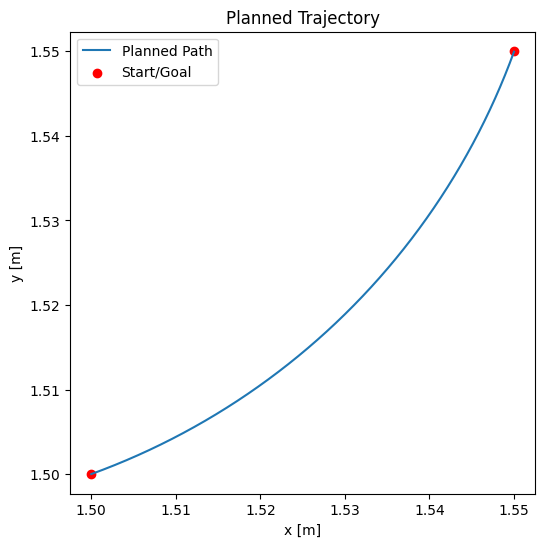

In [6]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=20)
goal = FriendlyPose(x=1.55, y=1.55, theta_deg=0.0)

plan, new_heading = connect_poses_with_curvature(ps, start, goal)
print(plan)
print(new_heading)

# Simulate and plot
xs, ys, thetas = simulate_plan(start, [plan])

plt.figure(figsize=(6,6))
plt.plot(xs, ys, label="Planned Path")
plt.scatter([start.x, goal.x], [start.y, goal.y], c='red', label="Start/Goal")
plt.axis('equal')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Planned Trajectory")
plt.legend()
plt.show()

PlanStep
│ duration: 2.0412005386857492
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: -156.77048576816256
20.0


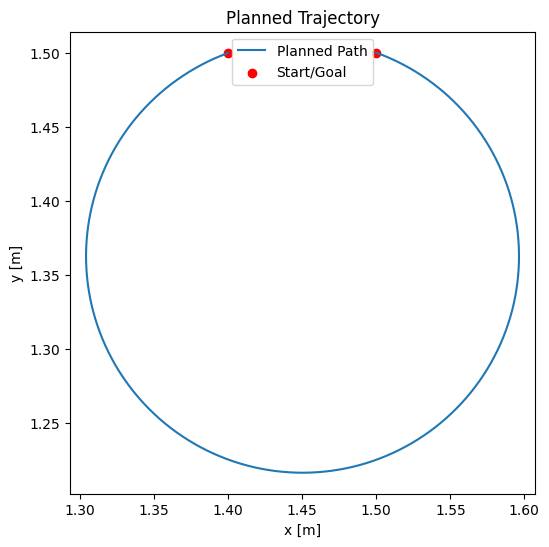

In [7]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=340)
goal = FriendlyPose(x=1.40, y=1.50, theta_deg=20.0)

plan, new_heading = connect_poses_with_curvature(ps, start, goal)
print(plan)
print(new_heading)

# Simulate and plot
xs, ys, thetas = simulate_plan(start, [plan])

plt.figure(figsize=(6,6))
plt.plot(xs, ys, label="Planned Path")
plt.scatter([start.x, goal.x], [start.y, goal.y], c='red', label="Start/Goal")
plt.axis('equal')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Planned Trajectory")
plt.legend()
plt.show()

In [10]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=20)
solution = []
window = (3.0 - 0.0) / 6
for i in np.arange(-window, window, 0.05):
    for j in np.arange(-window, window, 0.05):
        if abs(i) < 1e-12 and abs(j) < 1e-12:
            continue
        goal = FriendlyPose(x=1.5 + i, y=1.5 + j, theta_deg=0.0)
        plan, new_heading = connect_poses_with_curvature(ps, start, goal)
        if round(new_heading) % 20 == 0:
            print(f"coordinates: {i}, {j}, heading: {new_heading}")
            solution.append((i, j))

print(len(solution))

coordinates: -0.5, -1.1102230246251565e-16, heading: 340.0
coordinates: -0.45, -1.1102230246251565e-16, heading: 340.0
coordinates: -0.4, -1.1102230246251565e-16, heading: 340.0
coordinates: -0.35000000000000003, -1.1102230246251565e-16, heading: 340.0
coordinates: -0.30000000000000004, -0.25000000000000006, heading: 59.61114218453042
coordinates: -0.30000000000000004, -1.1102230246251565e-16, heading: 340.0
coordinates: -0.30000000000000004, 0.24999999999999978, heading: 260.38885781546963
coordinates: -0.25000000000000006, -0.30000000000000004, heading: 80.38885781546958
coordinates: -0.25000000000000006, -1.1102230246251565e-16, heading: 340.0
coordinates: -0.25000000000000006, 0.2999999999999998, heading: 239.61114218453042
coordinates: -0.20000000000000007, -1.1102230246251565e-16, heading: 340.0
coordinates: -0.15000000000000008, -1.1102230246251565e-16, heading: 340.0
coordinates: -0.10000000000000009, -1.1102230246251565e-16, heading: 340.0
coordinates: -0.0500000000000001, -1.